## khảo sát dữ liệu

### Import các thư viện cần thiết

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Lấy code trong file data/data.csv

In [55]:
df=pd.read_csv('data/AirQuality.csv')
print(df.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  PT08.S2(NMHC)  NOx(GT)  \
0  3/10/2004  18:00:00     2.6       1360.0     150.0         1046.0    166.0   
1  3/10/2004  19:00:00     2.0       1292.0     112.0          955.0    103.0   
2  3/10/2004  20:00:00     2.2       1402.0      88.0          939.0    131.0   
3  3/10/2004  21:00:00     2.2       1376.0      80.0          948.0    172.0   
4  3/10/2004  22:00:00     1.6       1272.0      51.0          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  \
0        1056.0    113.0        1692.0       1268.0  13.6  48.9  0.7578   
1        1174.0     92.0        1559.0        972.0  13.3  47.7  0.7255   
2        1140.0    114.0        1555.0       1074.0  11.9  54.0  0.7502   
3        1092.0    122.0        1584.0       1203.0  11.0  60.0  0.7867   
4        1205.0    116.0        1490.0       1110.0  11.2  59.6  0.7888   

   C6H6(GT)  
0      11.9  
1       9.4  
2       9.0  
3     

### Kiểm tra trùng lặp

In [56]:
duplicates = df.duplicated().sum()
print(f"Số lượng dòng trùng lắp: {duplicates}")
df.drop_duplicates(inplace=True)

Số lượng dòng trùng lắp: 0


### Xem thông tin của data

In [57]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        7718 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        7715 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
 14  C6H6(GT)       8991 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB
None


### Thống kê mô tả

In [44]:
print(df.describe())

            CO(GT)  PT08.S1(CO)     NMHC(GT)  PT08.S2(NMHC)      NOx(GT)  \
count  7674.000000  8991.000000   914.000000    8991.000000  7718.000000   
mean      2.152750  1099.833166   218.811816     939.153376   246.896735   
std       1.453252   217.080037   204.459921     266.831429   212.979168   
min       0.100000   647.000000     7.000000     383.000000     2.000000   
25%       1.100000   937.000000    67.000000     734.500000    98.000000   
50%       1.800000  1063.000000   150.000000     909.000000   180.000000   
75%       2.900000  1231.000000   297.000000    1116.000000   326.000000   
max      11.900000  2040.000000  1189.000000    2214.000000  1479.000000   

       PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)            T  \
count   8991.000000  7715.000000   8991.000000  8991.000000  8991.000000   
mean     835.493605   113.091251   1456.264598  1022.906128    18.317829   
std      256.817320    48.370108    346.206794   398.484288     8.832116   
min      32

### Phân phối histogram và boxplot cho từng thuộc tính của data

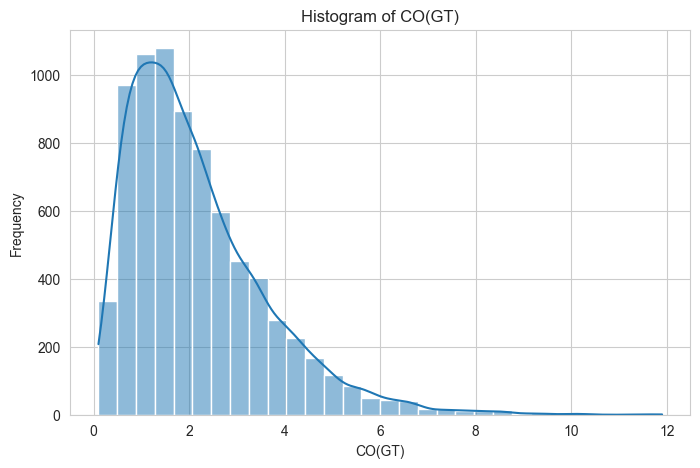

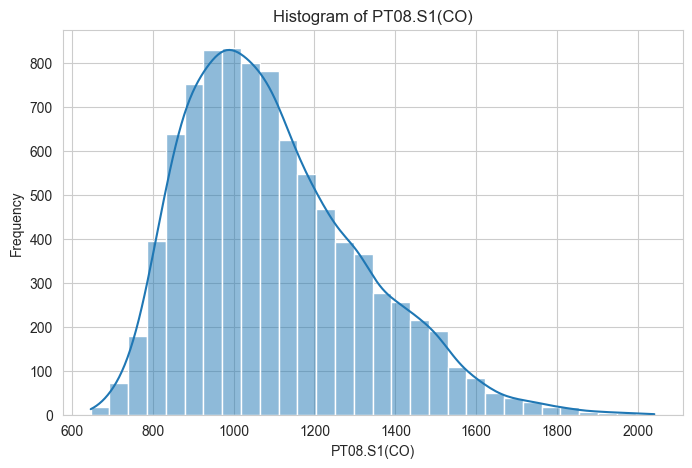

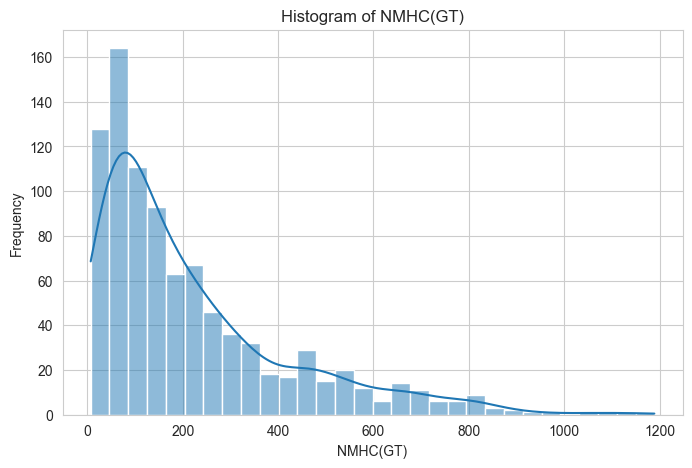

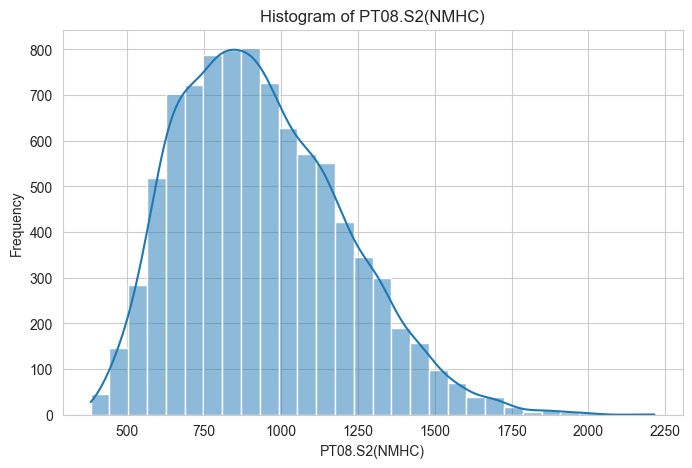

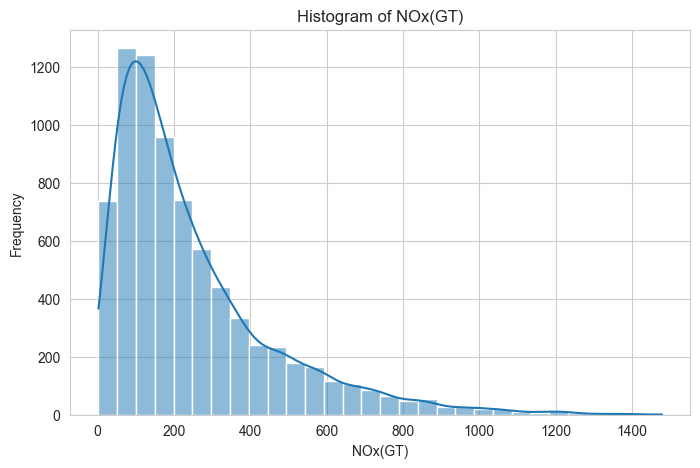

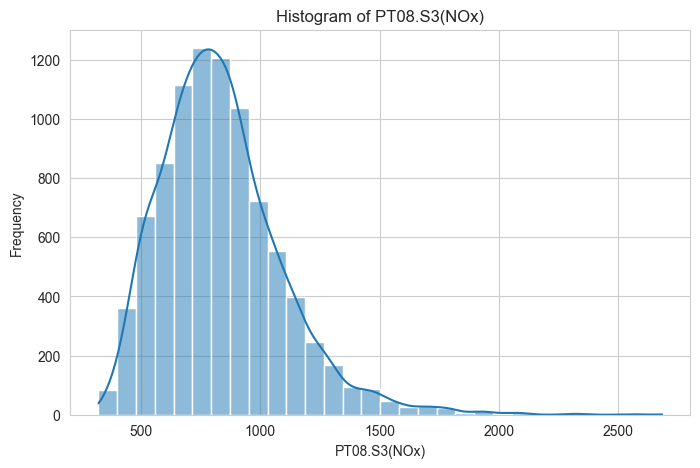

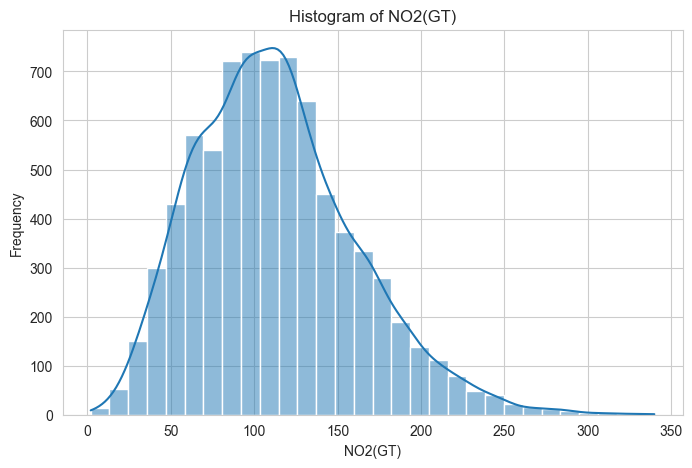

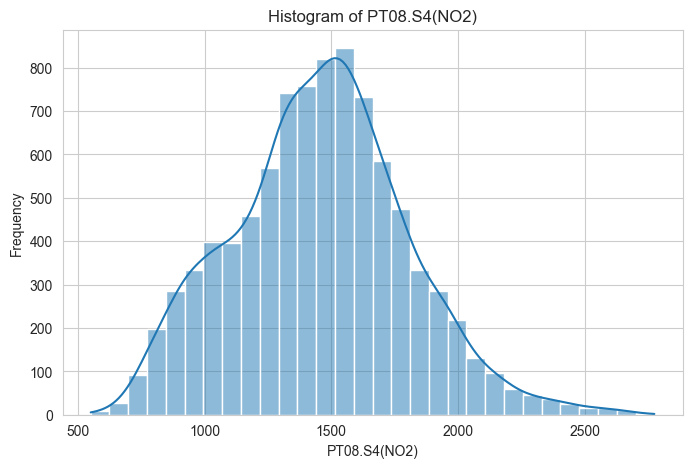

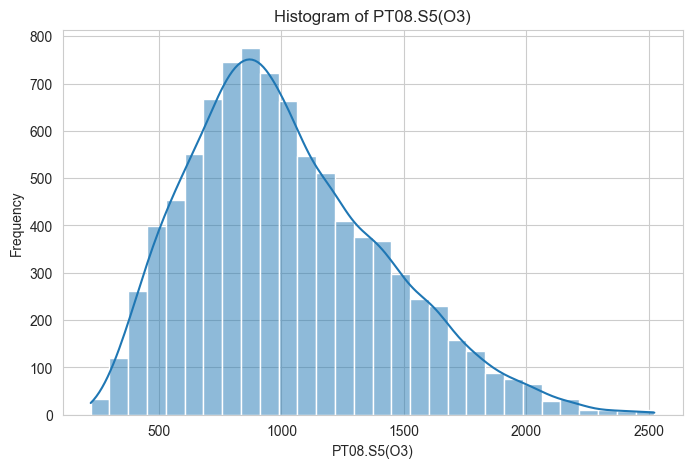

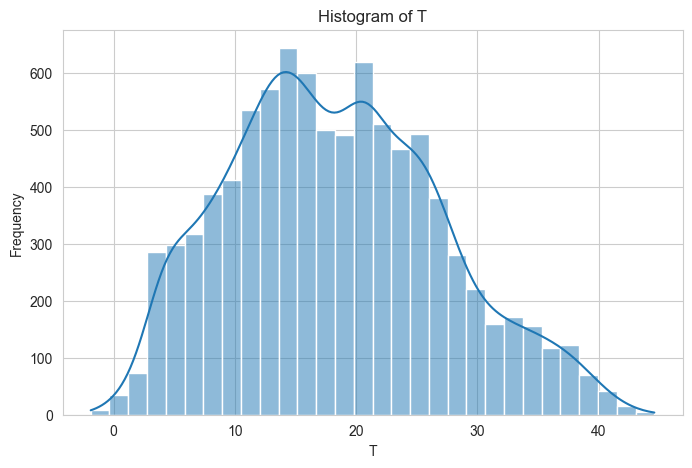

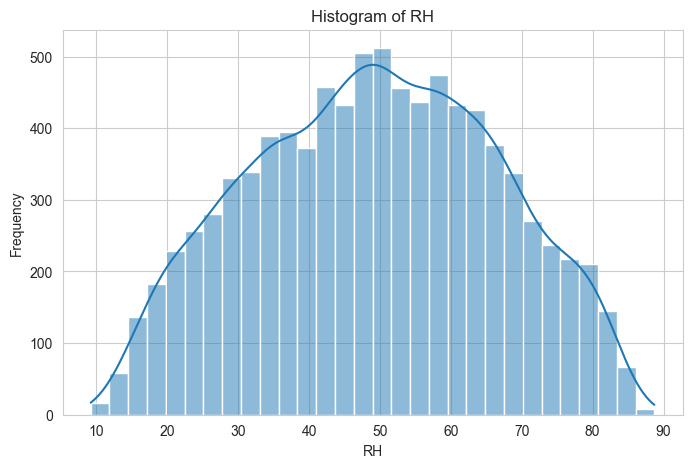

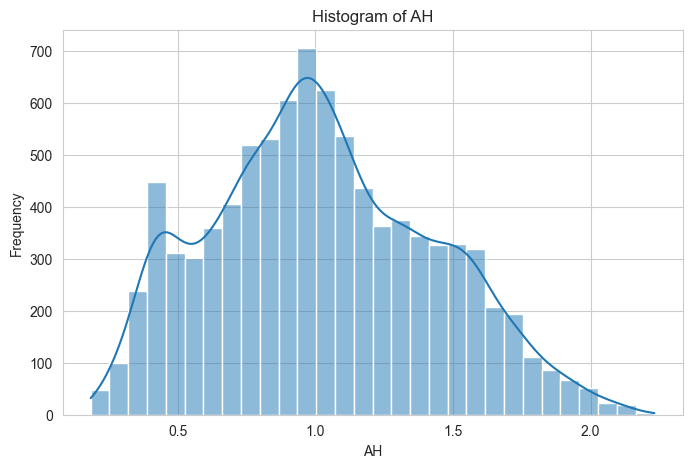

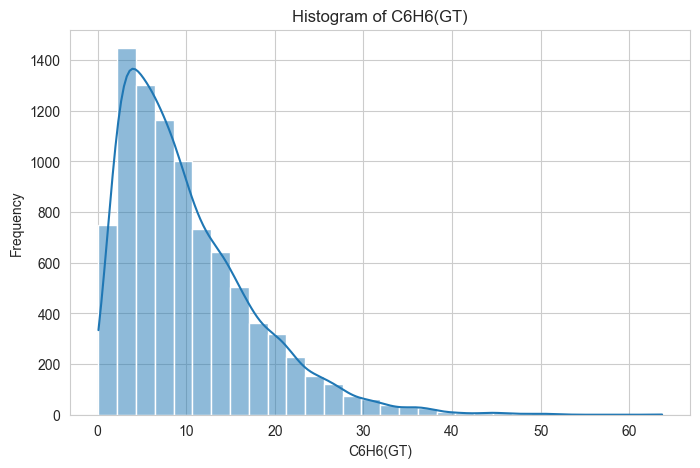

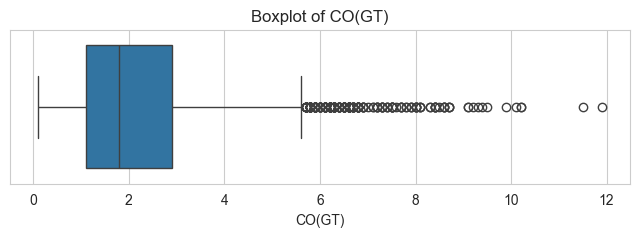

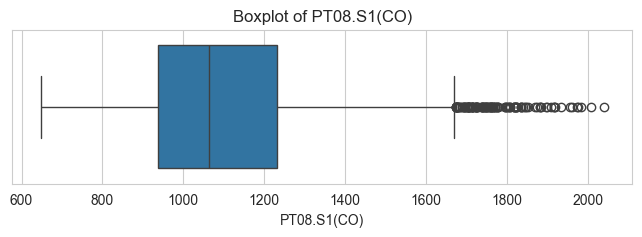

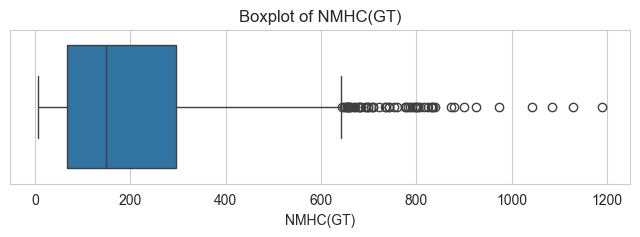

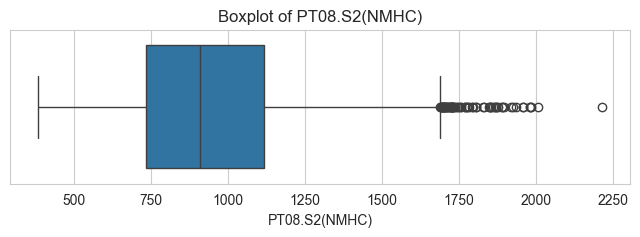

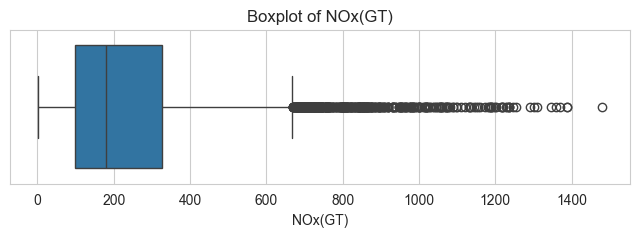

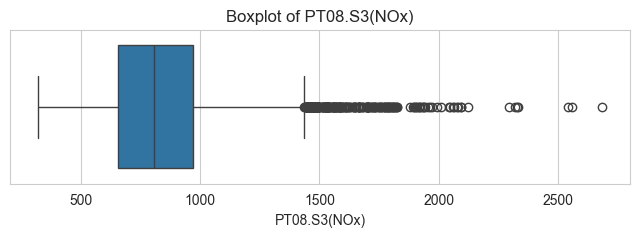

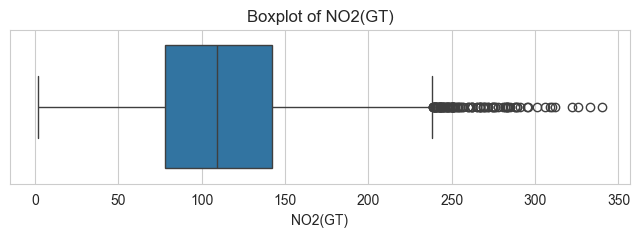

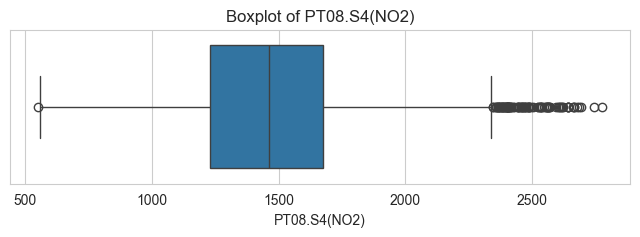

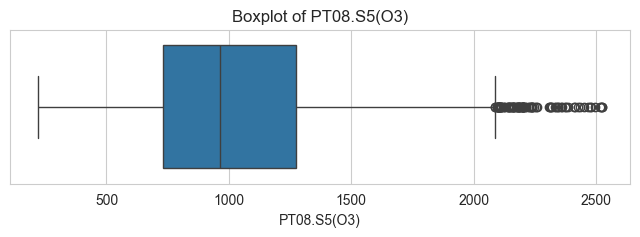

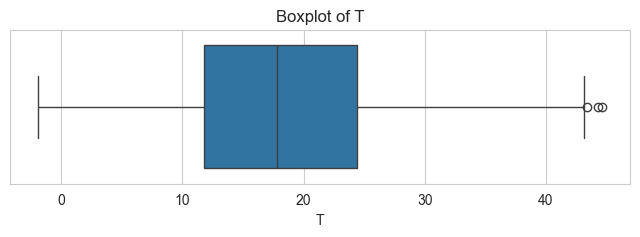

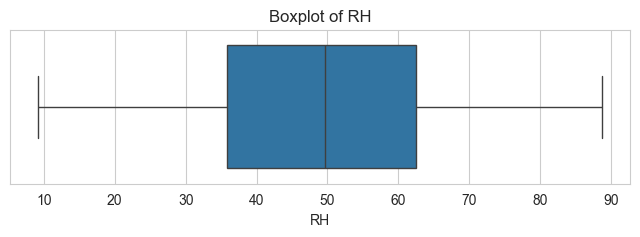

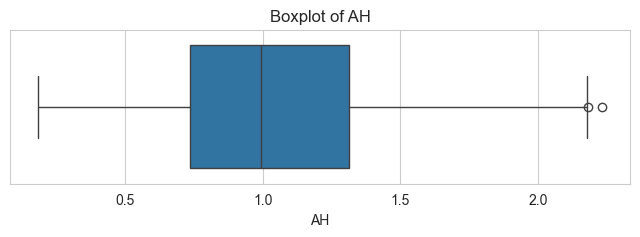

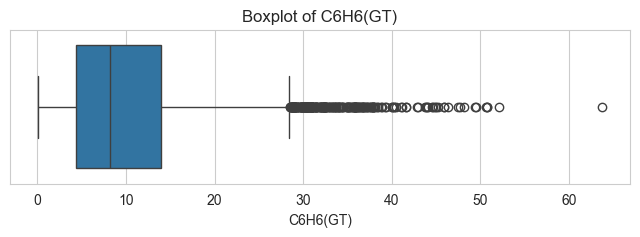

In [51]:
# lấy tất cả cột dạng số
numeric_columns = df.select_dtypes(include=['number']).columns

# style đẹp hơn
sns.set_style("whitegrid")

# =========================
# HISTPLOT
# =========================
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True
    )
    
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

# =========================
# BOXPLOT
# =========================
for col in numeric_columns:
    plt.figure(figsize=(8, 2))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

### Trích xuất đặc trưng thời gian và xử lí dữ liệu ở DataFrame tạm để vẽ heatmap

In [46]:
df_temp=df.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp['Month'] = df_temp['Date'].dt.month
df_temp['DayOfWeek'] = df_temp['Date'].dt.dayofweek # 0: Thứ 2, 6: Chủ nhật

# Xử lý Time
df_temp['Hour'] = pd.to_datetime(df_temp['Time'], format='%H:%M:%S').dt.hour

# Loại bỏ cột gốc sau khi đã trích xuất
df_numerics = df_temp.drop(columns=['Date', 'Time'])

### Heatmap tương quan giữa các thành phần

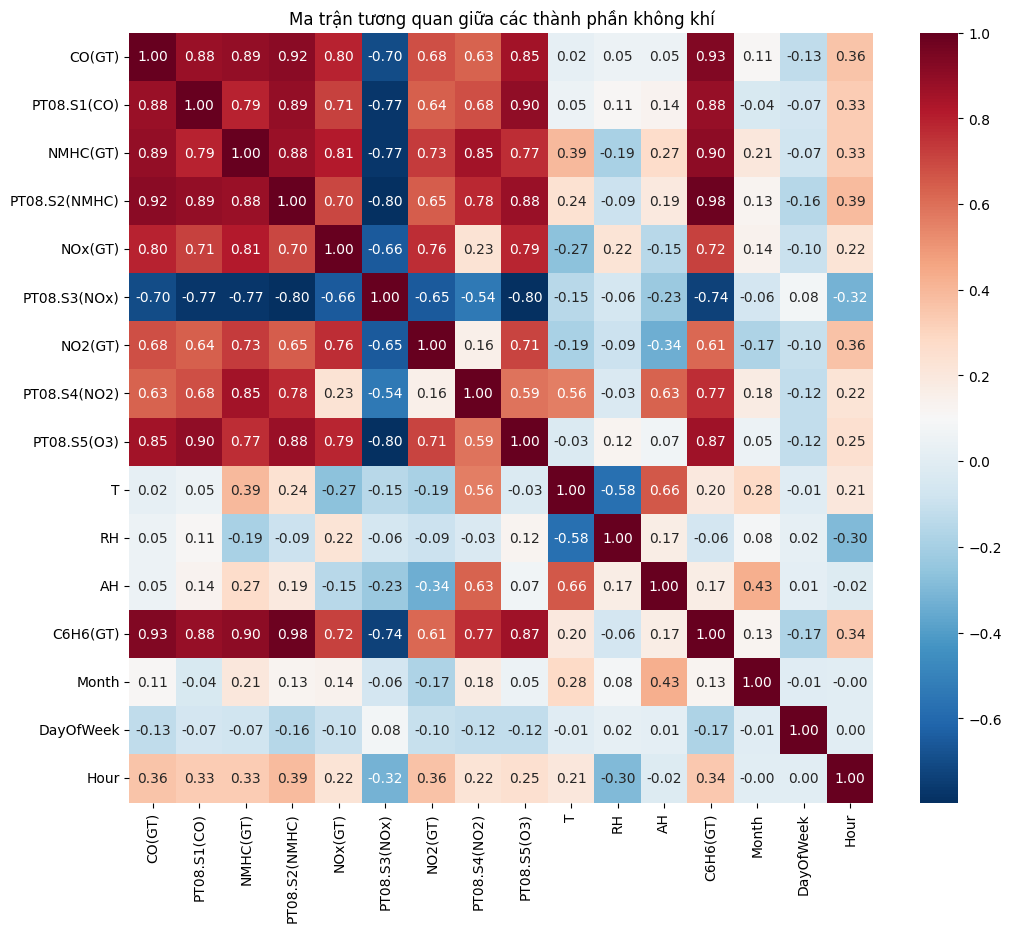

In [47]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_numerics.corr(), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Ma trận tương quan giữa các thành phần không khí')
plt.show()

### Missing values

In [48]:
missing_rate=df.isnull().mean()*100
print(missing_rate)

Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
C6H6(GT)          3.911510
dtype: float64


### Khảo sát ourliers của mỗi cột

In [54]:
import pandas as pd

numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:

    temp = df[col].dropna()

    Q1 = temp.quantile(0.25)
    Q3 = temp.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = temp[
        (temp < lower) |
        (temp > upper)
    ]

    print("=" * 50)
    print(f"Column: {col}")
    print(f"Outliers: {len(outliers)}")
    print(f"Outlier Rate: {len(outliers)/len(temp)*100:.2f}%")

Column: CO(GT)
Outliers: 215
Outlier Rate: 2.80%
Column: PT08.S1(CO)
Outliers: 118
Outlier Rate: 1.31%
Column: NMHC(GT)
Outliers: 55
Outlier Rate: 6.02%
Column: PT08.S2(NMHC)
Outliers: 65
Outlier Rate: 0.72%
Column: NOx(GT)
Outliers: 435
Outlier Rate: 5.64%
Column: PT08.S3(NOx)
Outliers: 241
Outlier Rate: 2.68%
Column: NO2(GT)
Outliers: 107
Outlier Rate: 1.39%
Column: PT08.S4(NO2)
Outliers: 97
Outlier Rate: 1.08%
Column: PT08.S5(O3)
Outliers: 93
Outlier Rate: 1.03%
Column: T
Outliers: 3
Outlier Rate: 0.03%
Column: RH
Outliers: 0
Outlier Rate: 0.00%
Column: AH
Outliers: 2
Outlier Rate: 0.02%
Column: C6H6(GT)
Outliers: 228
Outlier Rate: 2.54%


## 2. Phân tích cơ chế Missing Value cho bộ dữ liệu Air Quality

Dựa trên đặc thù của dữ liệu cảm biến (*Sensor Data*), chúng ta cần biện luận để chọn phương pháp xử lý:

- **MCAR (Missing Completely At Random):**  
  Xảy ra nếu cảm biến mất tín hiệu ngẫu nhiên do nhiễu truyền dẫn. Tuy nhiên, trong file này, các giá trị thiếu thường đi theo cụm thời gian.

- **MAR (Missing At Random):**  
  Phổ biến nhất. Giá trị thiếu có thể phụ thuộc vào các biến khác (ví dụ: nhiệt độ quá cao làm cảm biến $CO$ tạm dừng hoạt động).

- **MNAR (Missing Not At Random):**  
  Xảy ra nếu cảm biến không thể đo được khi nồng độ chất ô nhiễm vượt quá ngưỡng tối đa/tối thiểu của nó.

> **Kết luận:**  
> Với dữ liệu này, cơ chế khả dĩ nhất là **MAR**. Do đó, ta không nên xóa dòng (*Listwise Deletion*) mà nên dùng **Imputation** (*Mean/Median hoặc Regression Imputation*) để bảo toàn thông tin.\
> Với các cột thuộc tính có tỉ lệ missing quá cao thì ta loại bỏ thuộc tính đó ra khỏi dữ liệu để đảm bảo đáng tin cậy, khi ta điền bằng các phương pháp như Imputation vào quá nhiều dòng trong 1 cột thì dữ liệu đó sẽ trở nên không đáng tin cậy.